# TMD (paper-style) demo: barcode, density profile, persistence image

This notebook demonstrates how to:
1. Prepare a rooted NetworkX tree with `pos` attributes and `G.graph["root"]`.
2. Compute **paper-style TMD barcodes** from a scalar function (filtration).
3. Convert the barcode into:
   - a **1D density profile embedding**
   - an (optional) **persistence image** embedding
4. Plot: tree, barcode, persistence diagram, persistence image, density profile.


In [31]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import os, sys
from pathlib import Path
sys.path.append(os.path.abspath('..'))

from utils.tmd_conditioning_utils import (
    filtration_path_length_from_root,
    filtration_height_z,
    filtration_radial_rho,
    normalize_filtration_values,
    persistence_image,
)

from utils.tmd_paper_embedding_utils import (
    root_undirected_tree,
    build_critical_tree,
    compute_tmd_barcode,
    barcode_to_diagram,
    barcode_density_profile,
    compute_tmd_global_embedding_paper,
)

from utils.data_loading import load_swc_graphs_from_dir, load_swc_graph


## 1) Load rooted trees from your dataset (SWC)

This uses `utils.data_loading.load_swc_graphs_from_dir` to read cleaned `.csv.swc` files into
NetworkX trees with `G.graph['root']` and `G.nodes[n]['pos']` already set.

Expected folder layout (same as training): `DATA_ROOT/{train,val,test}`.


In [72]:
# Point this at your cleaned SWC dataset root
DATA_ROOT = Path('/Volumes/Seagate/small_trees_test_v3')  # <-- change to your dataset root
SPLIT = 'train'  # 'train' | 'val' | 'test'
SWC_DIR = DATA_ROOT / SPLIT

# Option A: load a directory of SWC files
graphs = load_swc_graphs_from_dir(SWC_DIR)
if len(graphs) == 0:
    raise RuntimeError(f'No SWC graphs found under: {SWC_DIR}')
print(f'Loaded {len(graphs)} graphs from {SWC_DIR}')

# Pick one tree to visualize in the next sections
GRAPH_IDX = 2
G = graphs[GRAPH_IDX]

# Option B (single file):
# SINGLE_SWC = Path('/path/to/file.csv.swc')
# G = load_swc_graph(SINGLE_SWC)


Loaded 3 graphs from /Volumes/Seagate/small_trees_test_v3/train


## 1b) Compute TMD barcode + PI for a batch of dataset trees

This computes a **paper-style TMD barcode** and a **persistence image** for each tree.


In [73]:
def compute_tmd_and_pi(G, *, filtration='path', n_bins=32, sigma=0.05, weighting='none'):
    root = G.graph['root']
    rooted_full = root_undirected_tree(G, root)
    rooted_crit = build_critical_tree(rooted_full)

    if filtration == 'path':
        f = filtration_path_length_from_root(G, weight_edges_by_euclidean=True)
    elif filtration == 'height':
        f = filtration_height_z(G)
    elif filtration == 'rho':
        f = filtration_radial_rho(G)
    else:
        raise ValueError(f'Unknown filtration: {filtration!r}')

    f = normalize_filtration_values(f, mode='minmax')
    f_crit = {n: float(f[n]) for n in rooted_crit.children.keys()}

    barcode = compute_tmd_barcode(rooted_crit, f_crit)
    diag = barcode_to_diagram(barcode)
    pi = persistence_image(diag, n_bins=n_bins, sigma=sigma, weighting=weighting)
    return barcode, diag, pi

MAX_GRAPHS = 50  # limit for speed; raise if you want the full dataset
n_use = min(MAX_GRAPHS, len(graphs))

tmd_barcodes = []
tmd_diagrams = []
tmd_pis = []

for Gi in graphs[:n_use]:
    barcode, diag, pi = compute_tmd_and_pi(Gi, filtration='path')
    tmd_barcodes.append(barcode)
    tmd_diagrams.append(diag)
    tmd_pis.append(pi)

tmd_pis = np.stack(tmd_pis, axis=0)
print('Computed TMD+PI for', n_use, 'graphs')
print('tmd_pis shape:', tmd_pis.shape)


Computed TMD+PI for 3 graphs
tmd_pis shape: (3, 1024)


## 2) Visualize the tree (3D scatter + edges)

(If you have very large trees, consider downsampling for plotting.)


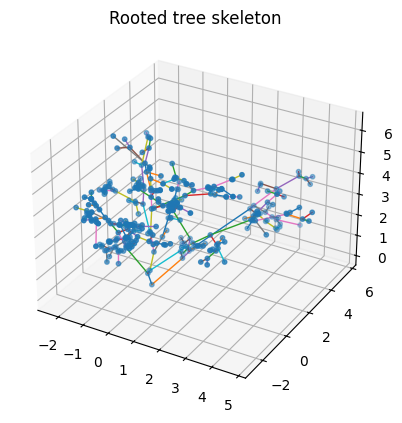

In [74]:
# Basic 3D plot of the skeleton
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# nodes
xyz = np.stack([G.nodes[n]["pos"] for n in G.nodes], axis=0)
ax.scatter(xyz[:,0], xyz[:,1], xyz[:,2], s=10)

# edges
for u, v in G.edges:
    pu = G.nodes[u]["pos"]
    pv = G.nodes[v]["pos"]
    ax.plot([pu[0], pv[0]], [pu[1], pv[1]], [pu[2], pv[2]], linewidth=1)

ax.set_title("Rooted tree skeleton")
plt.show()


## 3) Compute a paper-style TMD barcode for one filtration

We'll use `path` by default (path length from root), then normalize to [0,1].


In [75]:
root = G.graph["root"]
rooted_full = root_undirected_tree(G, root)
rooted_crit = build_critical_tree(rooted_full)

# Choose filtration: path / height / rho
f = filtration_path_length_from_root(G, weight_edges_by_euclidean=True)
f = normalize_filtration_values(f, mode="minmax")

# Restrict to critical nodes (recommended)
f_crit = {n: float(f[n]) for n in rooted_crit.children.keys()}

barcode = compute_tmd_barcode(rooted_crit, f_crit)
print("barcode shape:", barcode.shape)
barcode[:10]


barcode shape: (164, 2)


array([[0.64494258, 0.62322359],
       [0.68707662, 0.66060188],
       [0.68974492, 0.6571265 ],
       [0.65643657, 0.58776277],
       [0.63685907, 0.62219439],
       [0.70738923, 0.64746904],
       [0.65968896, 0.60216531],
       [0.70093721, 0.52733891],
       [0.62022708, 0.61035879],
       [0.64558145, 0.61946718]])

## 4) Plot barcode and persistence diagram


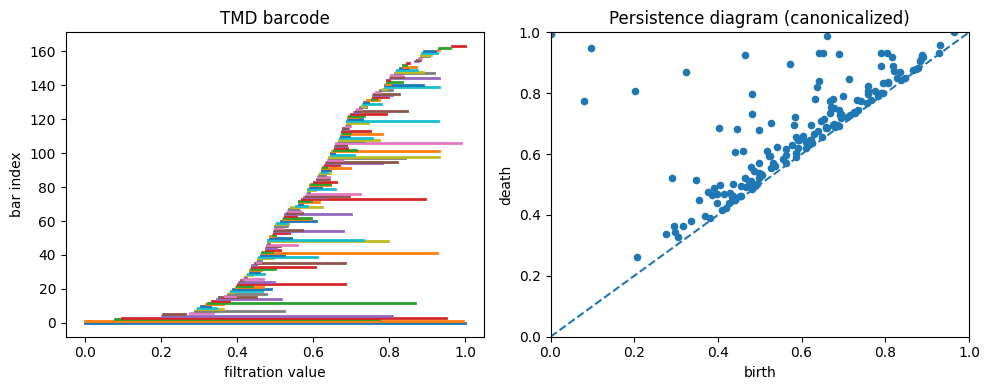

In [76]:
def plot_barcode(barcode, ax=None):
    if ax is None:
        ax = plt.gca()
    # canonicalize for plotting
    lo = np.minimum(barcode[:,0], barcode[:,1])
    hi = np.maximum(barcode[:,0], barcode[:,1])
    order = np.argsort(lo)  # sort by birth
    for i, idx in enumerate(order):
        ax.plot([lo[idx], hi[idx]], [i, i], linewidth=2)
    ax.set_xlabel("filtration value")
    ax.set_ylabel("bar index")
    ax.set_title("TMD barcode")
    return ax

def plot_diagram(diag, ax=None):
    if ax is None:
        ax = plt.gca()
    b = diag.births
    d = diag.deaths
    ax.scatter(b, d, s=20)
    ax.plot([0,1],[0,1], linestyle="--")
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("birth"); ax.set_ylabel("death")
    ax.set_title("Persistence diagram (canonicalized)")
    return ax

diag = barcode_to_diagram(barcode)

fig, axs = plt.subplots(1,2, figsize=(10,4))
plot_barcode(barcode, ax=axs[0])
plot_diagram(diag, ax=axs[1])
plt.tight_layout()
plt.show()


## 5) Density profile (1D embedding) and persistence image (optional)


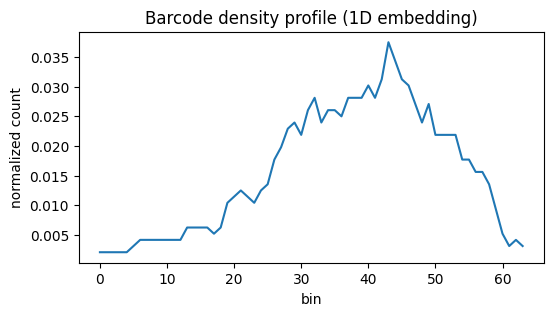

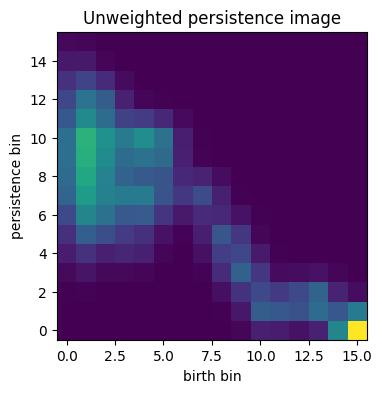

In [77]:
# Density profile (vector)
h = barcode_density_profile(barcode, n_bins=64, x_range=(0,1), normalize="l1")

plt.figure(figsize=(6,3))
plt.plot(h)
plt.title("Barcode density profile (1D embedding)")
plt.xlabel("bin"); plt.ylabel("normalized count")
plt.show()

# Persistence image embedding (vector) via your existing helper
pi = persistence_image(diag, n_bins=16, sigma=0.05, weighting="persistence")

plt.figure(figsize=(4,4))
plt.imshow(pi.reshape(16,16), origin="lower", aspect="auto")
plt.title("Unweighted persistence image")
plt.xlabel("birth bin"); plt.ylabel("persistence bin")
plt.show()


## 6) Full global embedding (multiple filtrations)

This matches the *input signature* of `compute_tmd_global_embedding` but uses the paper-style barcode.


In [63]:
vec = compute_tmd_global_embedding_paper(
    G,
    filtrations=("path","height","rho"),
    n_bins=16,
    sigma=0.05,
    normalize_mode="minmax",
    weighting="persistence",
    embedding="pi",   # try "pi" or "density+pi"
)
print("global vec shape:", vec.shape)
print(vec.mean())


global vec shape: (768,)
0.15817891
